# Random Forest (2/6) — Random Forest Regression

Same forest, predicting numbers: each tree predicts a value and the forest returns the **average**.

### In this notebook
1. Train a random forest regressor and predict a salary
2. Compare its curve with a single tree's
3. How the number of trees changes the curve
4. Final comparison: Decision Tree vs Random Forest vs SVR

> 📖 Theory: [`theory.md`](theory.md) §5 · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
X = dataset[['Level']].values        # 2-D: one feature column
y = dataset['Salary'].values
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


**Position Salaries:** 10 job levels and their salaries. It is a tiny demo dataset, so there is **no train/test
split**: we use it to *see* how each model draws its curve. The question: *a new hire says they were at level 6.5 and
earned 160,000. Is that believable?*

## 1. Train and predict

> ✍️ **Core code: learn this.** `RandomForestRegressor` averages the predictions of its trees.

In [3]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators=100, random_state=0)
regressor.fit(X, y)

print("Predicted salary for level 6.5:", round(regressor.predict([[6.5]])[0]))

Predicted salary for level 6.5: 158300


The forest predicts about **158,000** for level 6.5, between level 6 (150,000) and level 7 (200,000). That fits the
new hire's claim of 160,000. A single tree said exactly 150,000.

Why in between? Each tree saw a different bootstrap sample of the 10 rows, so their split points differ. Some trees
put 6.5 in level 6's leaf, others in a leaf mixed with level 7. The **average** of all those answers lands in between.

> ✍️ **Core code: learn this.** Look at what a few individual trees predict.

In [4]:
tree_preds = [tree.predict([[6.5]])[0] for tree in regressor.estimators_]
print("First 10 trees predict:", [round(p) for p in tree_preds[:10]])
print("Average of all 100    :", round(np.mean(tree_preds)))

First 10 trees predict: [200000, 110000, 150000, 150000, 150000, 300000, 150000, 200000, 110000, 150000]
Average of all 100    : 158300


## 2. Single tree vs forest

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

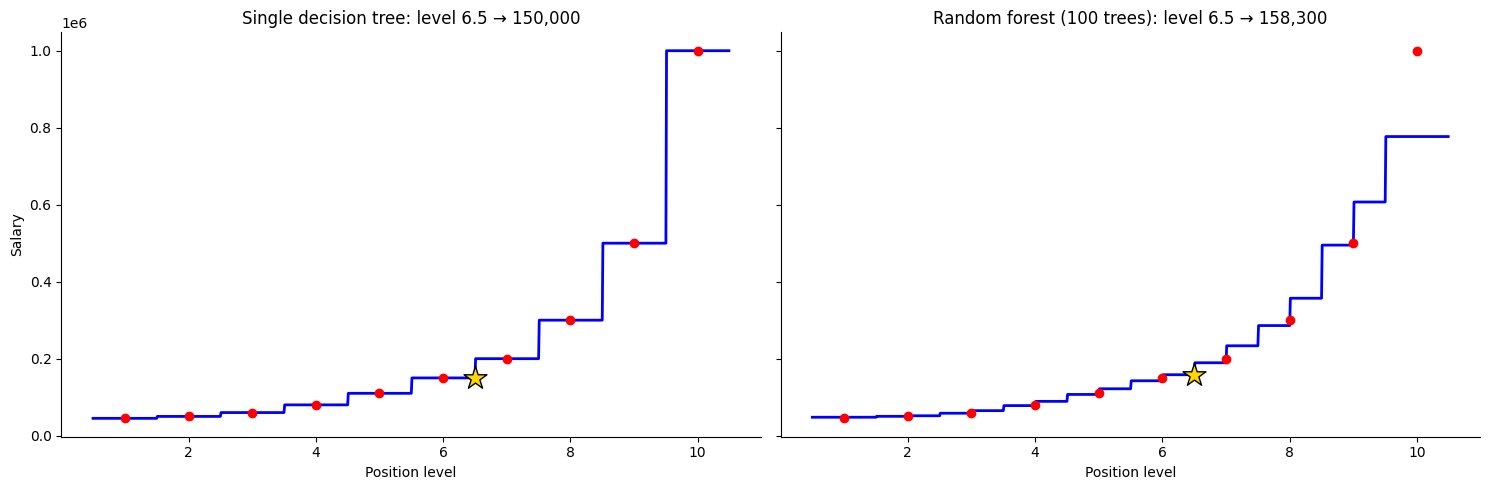

In [5]:
from sklearn.tree import DecisionTreeRegressor

X_grid = np.arange(0.5, 10.5, 0.01).reshape(-1, 1)
tree = DecisionTreeRegressor(random_state=0).fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, model, title in [(axes[0], tree, 'Single decision tree'), (axes[1], regressor, 'Random forest (100 trees)')]:
    ax.scatter(X, y, color='red', zorder=3)
    ax.plot(X_grid, model.predict(X_grid), color='blue', linewidth=2)
    ax.scatter([6.5], model.predict([[6.5]]), marker='*', s=300, color='gold', edgecolor='k', zorder=4)
    ax.set_title(f'{title}: level 6.5 → {model.predict([[6.5]])[0]:,.0f}')
    ax.set_xlabel('Position level')
axes[0].set_ylabel('Salary')
plt.tight_layout()
plt.show()

The forest's curve is still made of steps (it is an average of staircases), but it has **many more, smaller steps**,
and the jumps between levels are softer.

## 3. More trees, smoother steps

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

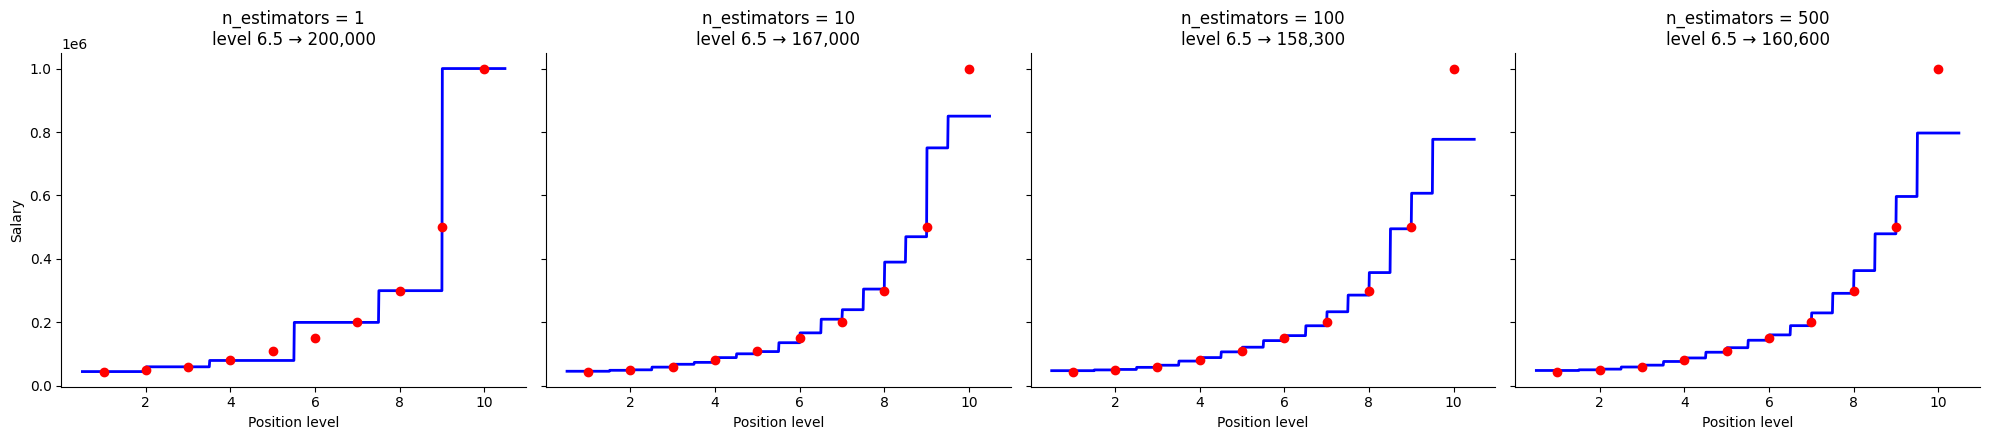

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for ax, n in zip(axes, [1, 10, 100, 500]):
    m = RandomForestRegressor(n_estimators=n, random_state=0).fit(X, y)
    ax.scatter(X, y, color='red', zorder=3)
    ax.plot(X_grid, m.predict(X_grid), color='blue', linewidth=2)
    ax.set_title(f'n_estimators = {n}\nlevel 6.5 → {m.predict([[6.5]])[0]:,.0f}')
    ax.set_xlabel('Position level')
axes[0].set_ylabel('Salary')
plt.tight_layout()
plt.show()

With 1 tree the prediction is jumpy and depends on one random sample. As trees are added, the average stabilises.

## 4. Final comparison: three non-linear regressors

> ✍️ **Core code: learn this.** Same data, same question, three models.

In [7]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

sc_X, sc_y = StandardScaler(), StandardScaler()
svr = SVR(kernel='rbf').fit(sc_X.fit_transform(X), sc_y.fit_transform(y.reshape(-1, 1)).ravel())
svr_pred = sc_y.inverse_transform(svr.predict(sc_X.transform([[6.5]])).reshape(-1, 1))[0, 0]

pd.DataFrame({
    'model': ['Decision Tree', 'Random Forest (100 trees)', 'SVR (rbf, Day 46)'],
    'prediction for level 6.5': [tree.predict([[6.5]])[0], regressor.predict([[6.5]])[0], svr_pred],
    'needs scaling?': ['no', 'no', 'yes'],
    'curve shape': ['staircase', 'many small steps', 'smooth'],
}).round(0)

,model,prediction for level 6.5,needs scaling?,curve shape
0,Decision Tree,150000.0,no,staircase
1,Random Forest (100 trees),158300.0,no,many small steps
2,"SVR (rbf, Day 46)",170370.0,yes,smooth


All three say the claimed 160,000 is **plausible** for level 6.5.

---
## Key takeaways
- Random forest regression = the **average** of many trees trained on bootstrap samples.
- Predictions are smoother and more stable than a single tree's.
- Like single trees, forests **cannot extrapolate** beyond the training range, and need no scaling.

📚 **More on random forests:** notebooks 03–06 in this folder cover bagging vs random forest, the OOB score, how
feature importance is calculated, and hyperparameter tuning.

➡️ **Next:** `03-bagging-vs-random-forest.ipynb`